2-BIT PCM
Levels (L): 4
Step Size: 0.5
Mean Square Error = 0.02620555581818377
Measured SQNR = 12.81 dB
Theoretical SQNR = 13.80 dB

First 20 Quantization Indices:
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3]

First 20 PCM Words:
['10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '11', '11', '11']


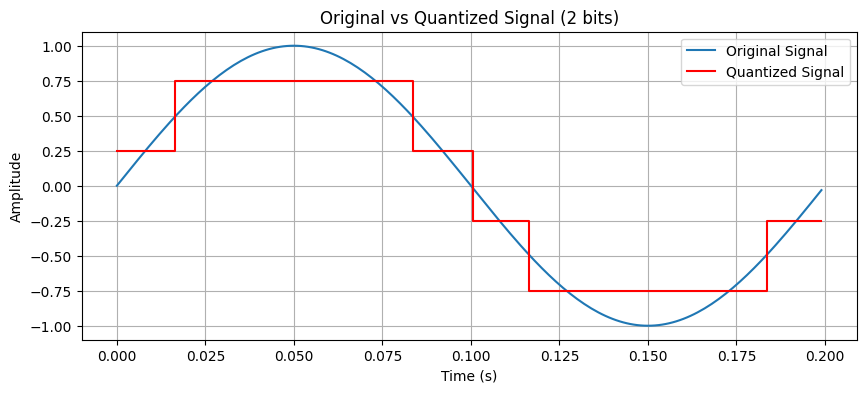

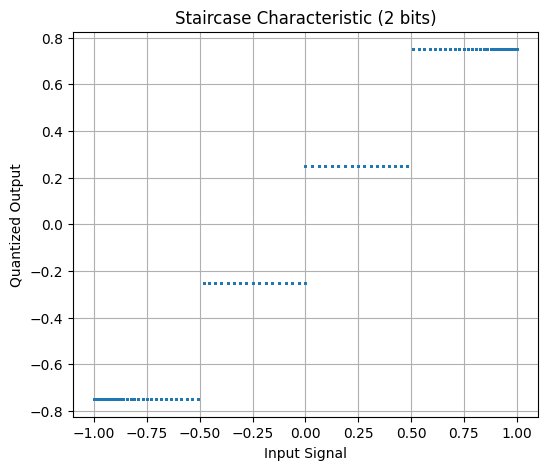

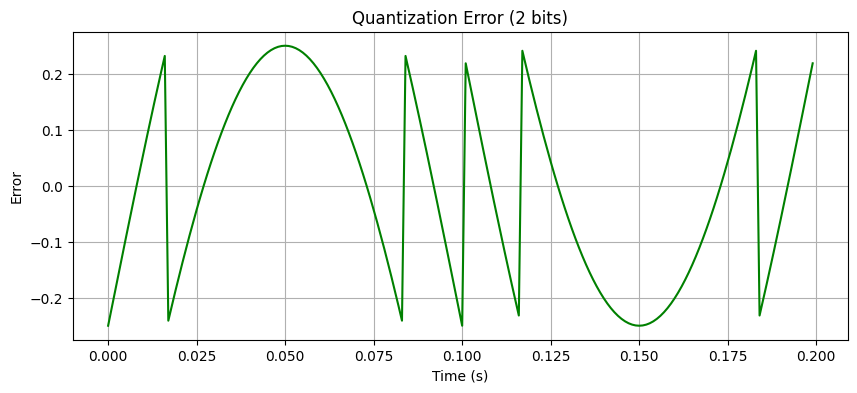

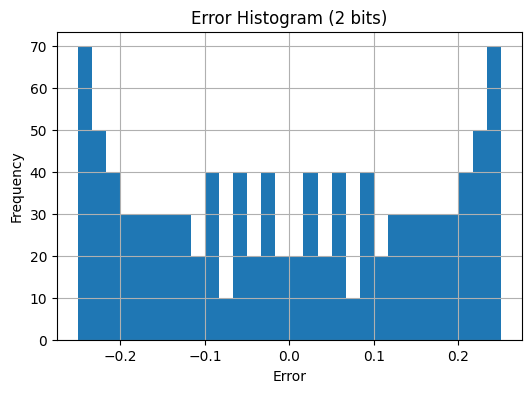

3-BIT PCM
Levels (L): 8
Step Size: 0.25
Mean Square Error = 0.006201642889140326
Measured SQNR = 19.06 dB
Theoretical SQNR = 19.82 dB

First 20 Quantization Indices:
[4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 6 6 6]

First 20 PCM Words:
['100', '100', '100', '100', '100', '100', '100', '100', '100', '101', '101', '101', '101', '101', '101', '101', '101', '110', '110', '110']


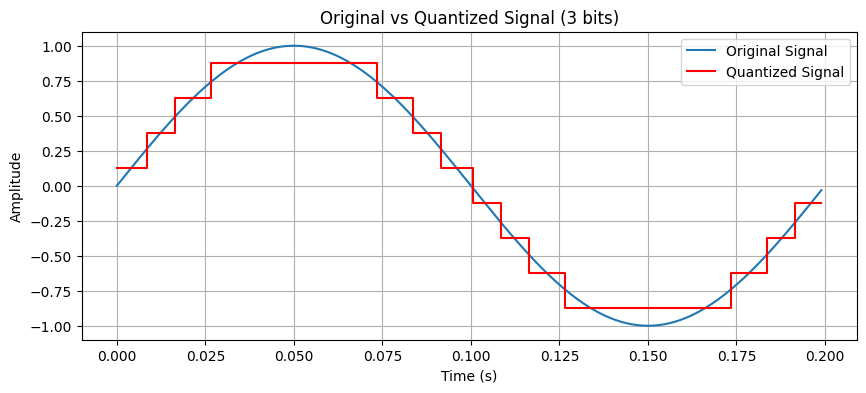

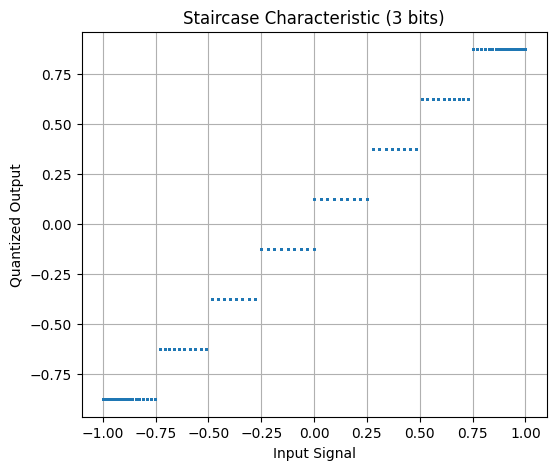

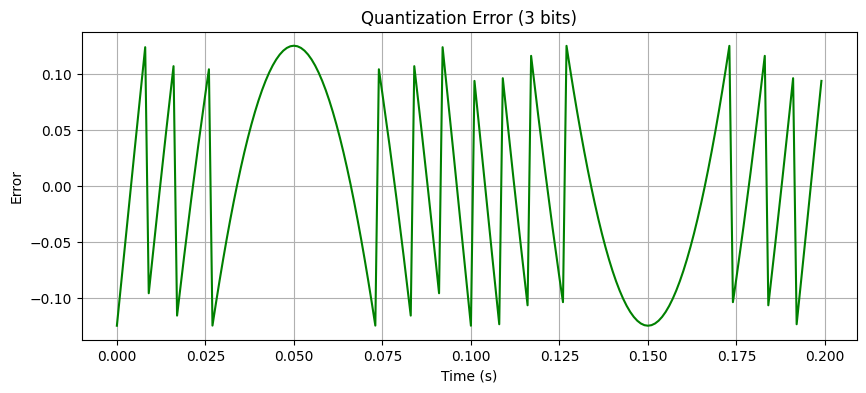

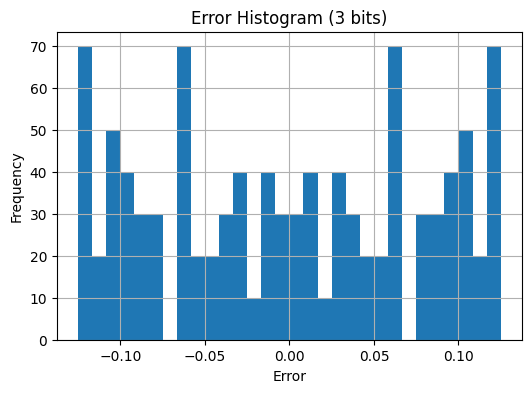

4-BIT PCM
Levels (L): 16
Step Size: 0.125
Mean Square Error = 0.0015008209642231368
Measured SQNR = 25.23 dB
Theoretical SQNR = 25.84 dB

First 20 Quantization Indices:
[ 8  8  8  8  9  9  9  9  9 10 10 10 10 11 11 11 11 12 12 12]

First 20 PCM Words:
['1000', '1000', '1000', '1000', '1001', '1001', '1001', '1001', '1001', '1010', '1010', '1010', '1010', '1011', '1011', '1011', '1011', '1100', '1100', '1100']


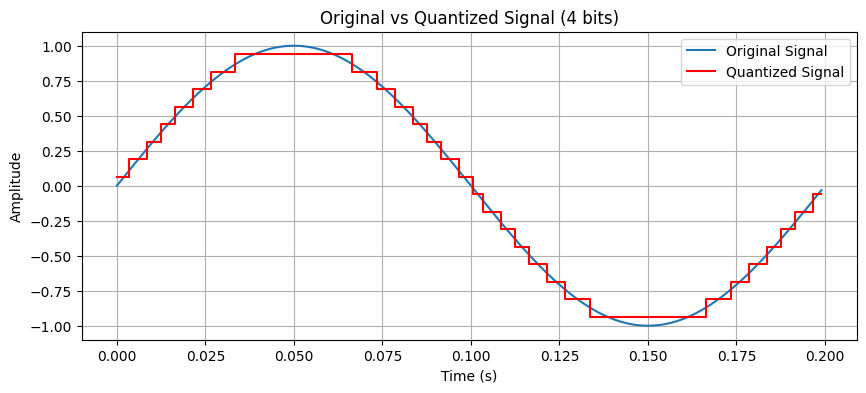

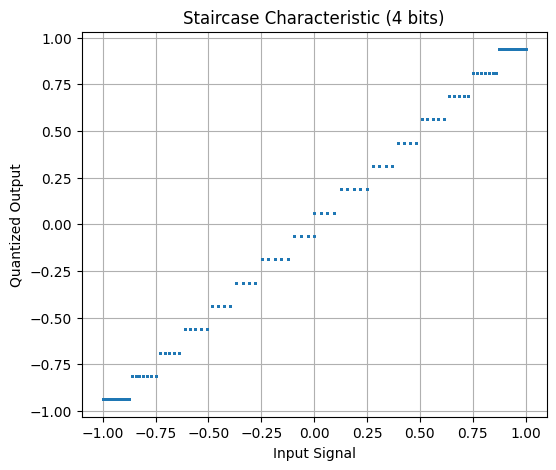

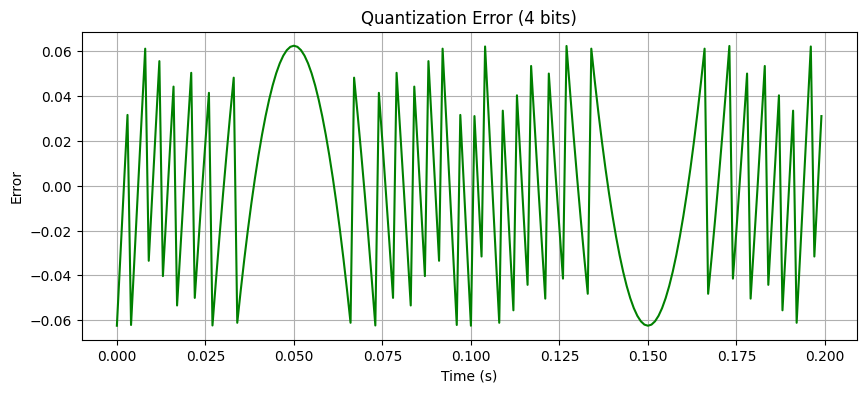

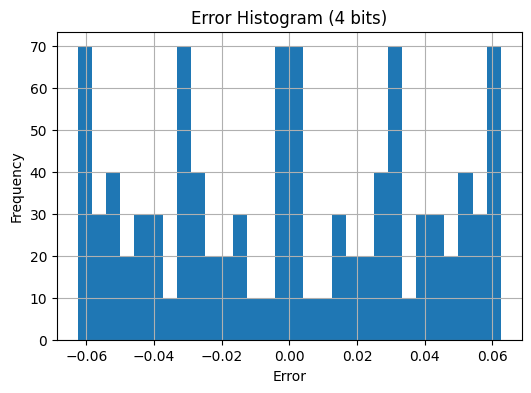

6-BIT PCM
Levels (L): 64
Step Size: 0.03125
Mean Square Error = 0.00011619888571320197
Measured SQNR = 36.34 dB
Theoretical SQNR = 37.88 dB

First 20 Quantization Indices:
[32 33 34 35 36 37 37 38 39 40 41 42 43 44 45 46 47 48 49 49]

First 20 PCM Words:
['100000', '100001', '100010', '100011', '100100', '100101', '100101', '100110', '100111', '101000', '101001', '101010', '101011', '101100', '101101', '101110', '101111', '110000', '110001', '110001']


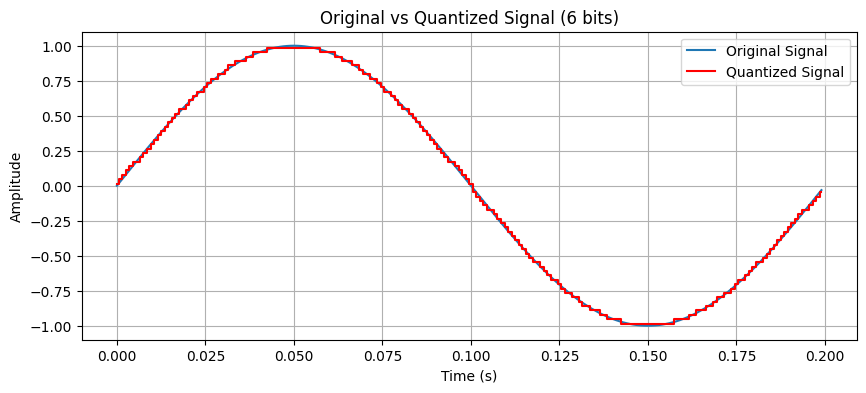

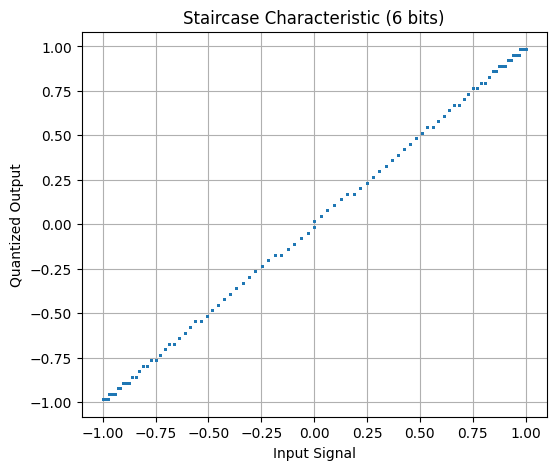

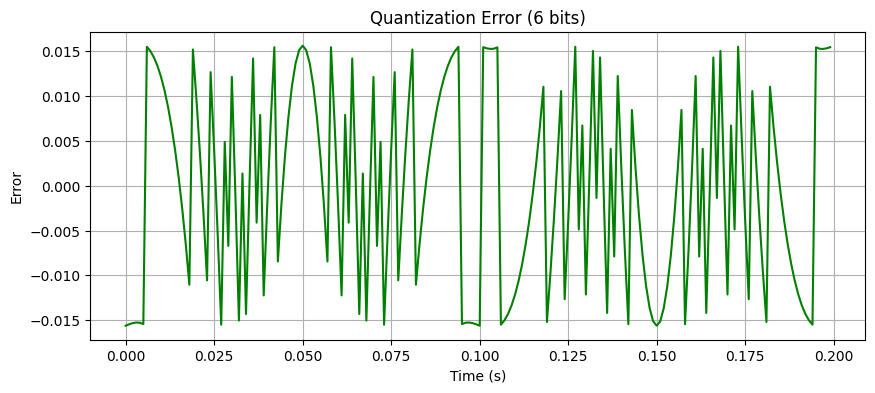

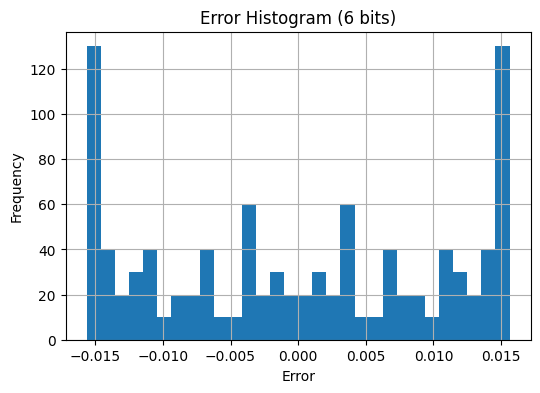

8-BIT PCM
Levels (L): 256
Step Size: 0.0078125
Mean Square Error = 6.7092402906320716e-06
Measured SQNR = 48.72 dB
Theoretical SQNR = 49.92 dB

First 20 Quantization Indices:
[128 132 136 140 144 148 151 155 159 163 167 171 175 178 182 186 189 193
 196 199]

First 20 PCM Words:
['10000000', '10000100', '10001000', '10001100', '10010000', '10010100', '10010111', '10011011', '10011111', '10100011', '10100111', '10101011', '10101111', '10110010', '10110110', '10111010', '10111101', '11000001', '11000100', '11000111']


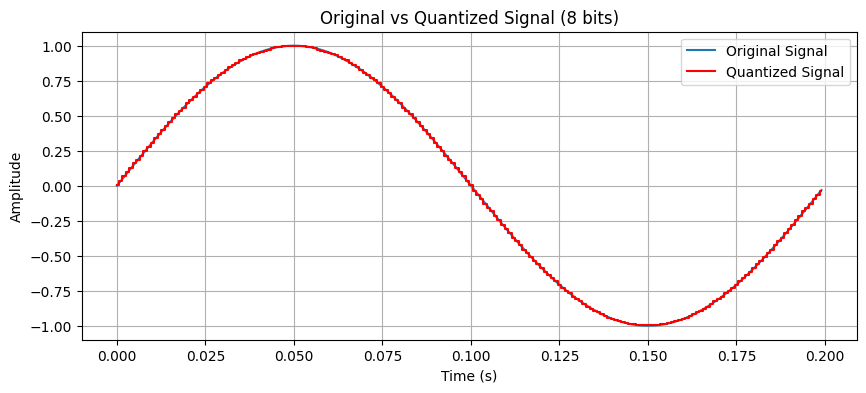

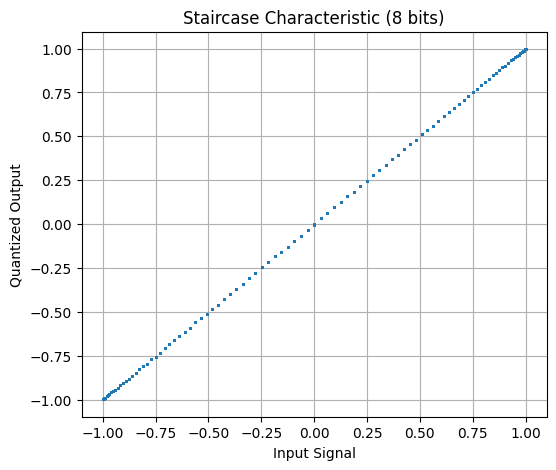

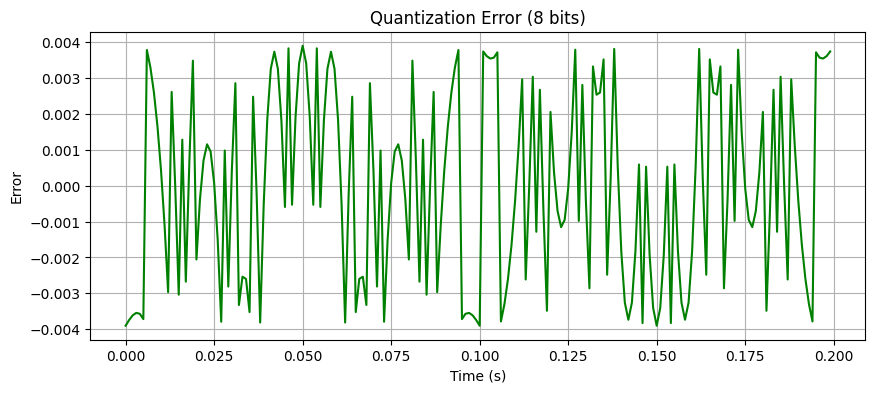

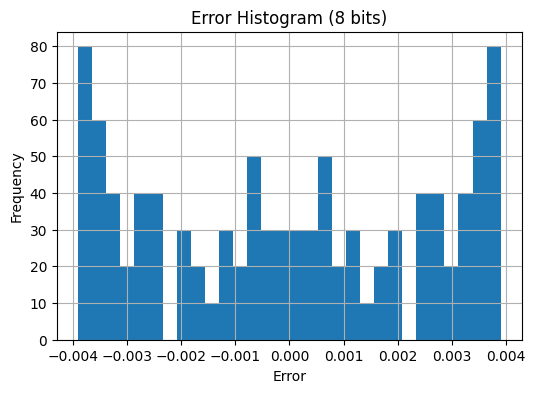

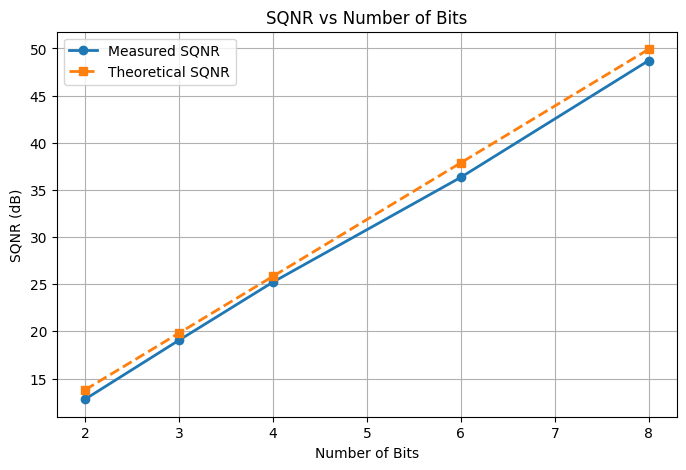


Experiment Completed Successfully!


In [1]:
# ============================================================
# Experiment 4: Uniform Quantization and PCM
# Google Colab Code
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Generate normalized sine wave
fs = 1000          # Sampling frequency
f = 5              # Signal frequency
t = np.arange(0, 1, 1/fs)
x = np.sin(2 * np.pi * f * t)    # Signal in [-1, 1]

bits_list = [2, 3, 4, 6, 8]
measured_sqnr = []
theoretical_sqnr = []

for n in bits_list:

    L = 2 ** n
    delta = 2 / L

    # Quantization Index
    index = np.floor((x + 1) / delta).astype(int)
    index = np.clip(index, 0, L - 1)

    # Quantized Signal
    xq = -1 + (index + 0.5) * delta

    # Quantization Error
    error = x - xq

    # Mean Square Error
    mse = np.mean(error ** 2)

    # Signal Power
    signal_power = np.mean(x ** 2)

    # SQNR
    sqnr = 10 * np.log10(signal_power / mse)

    measured_sqnr.append(sqnr)
    theoretical_sqnr.append(6.02 * n + 1.76)

    print("=" * 60)
    print(f"{n}-BIT PCM")
    print("=" * 60)
    print("Levels (L):", L)
    print("Step Size:", delta)
    print("Mean Square Error =", mse)
    print("Measured SQNR = %.2f dB" % sqnr)
    print("Theoretical SQNR = %.2f dB" % (6.02 * n + 1.76))

    # PCM Binary Words
    pcm = [format(i, '0{}b'.format(n)) for i in index]

    print("\nFirst 20 Quantization Indices:")
    print(index[:20])

    print("\nFirst 20 PCM Words:")
    print(pcm[:20])

    # Validation
    assert np.all(index >= 0)
    assert np.all(index < L)
    assert all(len(code) == n for code in pcm)

    # ---------------- Graph 1 ----------------
    plt.figure(figsize=(10,4))
    plt.plot(t[:200], x[:200], label='Original Signal')
    plt.step(t[:200], xq[:200], where='mid',
             color='red', label='Quantized Signal')
    plt.title(f'Original vs Quantized Signal ({n} bits)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.legend()
    plt.show()

    # ---------------- Graph 2 ----------------
    plt.figure(figsize=(6,5))
    plt.plot(x, xq, '.', markersize=2)
    plt.title(f'Staircase Characteristic ({n} bits)')
    plt.xlabel('Input Signal')
    plt.ylabel('Quantized Output')
    plt.grid(True)
    plt.show()

    # ---------------- Graph 3 ----------------
    plt.figure(figsize=(10,4))
    plt.plot(t[:200], error[:200], color='green')
    plt.title(f'Quantization Error ({n} bits)')
    plt.xlabel('Time (s)')
    plt.ylabel('Error')
    plt.grid(True)
    plt.show()

    # ---------------- Graph 4 ----------------
    plt.figure(figsize=(6,4))
    plt.hist(error, bins=30)
    plt.title(f'Error Histogram ({n} bits)')
    plt.xlabel('Error')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

# ---------------- Graph 5 ----------------
plt.figure(figsize=(8,5))
plt.plot(bits_list, measured_sqnr, 'o-', linewidth=2,
         label='Measured SQNR')
plt.plot(bits_list, theoretical_sqnr, 's--', linewidth=2,
         label='Theoretical SQNR')
plt.title("SQNR vs Number of Bits")
plt.xlabel("Number of Bits")
plt.ylabel("SQNR (dB)")
plt.grid(True)
plt.legend()
plt.show()

print("\nExperiment Completed Successfully!")